# Praktikum Machine Learning — Bab 5
## Decision Tree: Algoritma CART/ID3 dan Teknik Pruning

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini dikerjakan di **Google Colab / Jupyter Notebook**. Dataset dimuat langsung dari `sklearn.datasets` sehingga tidak memerlukan unduhan file eksternal.

## Ringkasan Konsep

**Decision Tree (pohon keputusan)** adalah model klasifikasi yang bekerja dengan membagi data secara **rekursif (recursive binary splitting)**: mulai dari *root node*, setiap *internal node* memilih satu fitur dan satu nilai ambang (*threshold*) untuk memisahkan data menjadi dua cabang, lalu proses ini diulang pada tiap cabang sampai terbentuk *leaf node* (daun) yang memuat label kelas prediksi. Jalur dari akar ke daun bisa dibaca sebagai aturan `if-then`, sehingga model ini sangat **interpretable**.

**Kriteria pemilihan split.** Untuk menentukan fitur dan threshold terbaik di tiap node, dipakai ukuran *ketidakmurnian* (impurity) node:
- **Gini impurity**: $Gini = 1 - \sum_{k} p_k^2$. Makin kecil makin murni. Cepat dihitung dan menjadi default di scikit-learn.
- **Entropy / Information Gain**: $Entropy = -\sum_{k} p_k \log_2(p_k)$, dan *Information Gain* = Entropy(induk) − Entropy(tertimbang anak). Split dengan Information Gain terbesar dipilih.

Keduanya umumnya memberi hasil mirip; Gini sedikit lebih cepat, Entropy sedikit lebih peka terhadap distribusi yang timpang.

**CART vs ID3.** *CART (Classification and Regression Trees)* menghasilkan pohon **biner** (tiap split selalu dua cabang) memakai kriteria Gini/Entropy, dipakai di `sklearn`. *ID3* memakai Information Gain dan dapat membuat cabang sebanyak kategori fitur (multi-way split) — cocok untuk fitur kategorikal, tetapi rentan bias ke fitur berkategori banyak.

**Overfitting pada tree.** Pohon tanpa batas tumbuh sampai tiap daun murni → akurasi latih 100%, tetapi akurasi uji menurun karena model menghafal *noise*. Solusinya adalah **pruning**:
- **Pre-pruning** (dipotong sebelum tumbuh): `max_depth` (batas kedalaman), `min_samples_leaf` (minimal sampel di daun), `min_samples_split`.
- **Post-pruning** (dipotong setelah tumbuh penuh): **Cost Complexity Pruning** dengan parameter `ccp_alpha` — cabang yang memberi perbaikan impurity lebih kecil dari `alpha` dipangkas. `alpha` optimal dipilih dari *pruning path*, bukan tebakan tunggal.

## Praktikum

### Praktikum 5.1 — Persiapan Library

Pertama, kita memuat semua library yang dibutuhkan: `numpy`/`pandas` untuk data, `matplotlib` untuk plot, lalu `load_breast_cancer`, `train_test_split`, `DecisionTreeClassifier`, `plot_tree`, dan metrik evaluasi dari scikit-learn.

In [1]:
%matplotlib inline
# Menjalankan di Google Colab / Jupyter Notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan output:**
- Tidak ada error `ModuleNotFoundError`, artinya `numpy`, `pandas`, `matplotlib`, dan `scikit-learn` tersedia di environment ini.
- Pesan `"Library berhasil dimuat."` tercetak — environment siap untuk praktikum.

### Praktikum 5.2 — Memuat Dataset Breast Cancer

Dataset **Breast Cancer Wisconsin** dimuat dengan `load_breast_cancer(as_frame=True)` sehingga fitur dan target tersedia sebagai DataFrame. Dataset ini berisi hasil pengukuran citra biopsi benjolan payudara dengan 2 kelas: `malignant` (ganas) dan `benign` (jinak). Kita cetak ukuran dataset dan distribusi kelasnya.

In [2]:
# Dataset dibaca dari file CSV lokal (data/breast_cancer.csv) — bisa dipakai offline
# (diekspor dari sklearn.datasets.load_breast_cancer, data real)
df = pd.read_csv('data/breast_cancer.csv')
feature_names = [c for c in df.columns if c not in ('target', 'target_name')]
target_names = ['malignant', 'benign']  # 0 = malignant, 1 = benign
X = df[feature_names]  # fitur: 30 hasil pengukuran citra biopsi
y = df['target']       # target: 0 = malignant, 1 = benign

print("Ukuran dataset (baris, kolom):", X.shape)
print("Jumlah fitur:", X.shape[1])
print("\nDaftar nama fitur (5 pertama):", list(X.columns[:5]))
print("\nDistribusi kelas:")
print(y.value_counts())
print("Nama kelas:", target_names)

Ukuran dataset (baris, kolom): (569, 30)
Jumlah fitur: 30

Daftar nama fitur (5 pertama): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

Distribusi kelas:
target
1    357
0    212
Name: count, dtype: int64
Nama kelas: ['malignant', 'benign']


**Penjelasan output:**
1. Dataset berukuran **(569, 30)** — 569 pasien, 30 fitur numerik (contoh: `mean radius`, `mean texture`).
2. Distribusi kelas **tidak seimbang tetapi tidak parah**: kelas `1 (benign)` = 357 data, kelas `0 (malignant)` = 212 data (rasio ± 1,68 : 1).
3. Karena sedikit timpang, pada pembagian data nanti kita pakai `stratify` agar proporsi kelas di data latih dan uji sama seperti data asli.

### Praktikum 5.3 — Pembagian Data Latih & Uji

Data dibagi menjadi **data latih (80%)** dan **data uji (20%)** dengan `stratify=y` supaya proporsi kelas `malignant`/`benign` tetap sama di kedua belah data. `random_state=42` dipakai agar hasil bisa direproduksi.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)
print("\nDistribusi kelas data latih:\n", y_train.value_counts())
print("\nDistribusi kelas data uji:\n", y_test.value_counts())

Ukuran data latih: (455, 30)
Ukuran data uji  : (114, 30)

Distribusi kelas data latih:
 target
1    285
0    170
Name: count, dtype: int64

Distribusi kelas data uji:
 target
1    72
0    42
Name: count, dtype: int64


**Penjelasan output:**
1. Data latih: **455 baris** (80% × 569), data uji: **114 baris** (20% × 569) — totalnya pas 569.
2. `stratify` bekerja dengan benar: data latih berisi 285 `benign` : 170 `malignant` dan data uji berisi 72 `benign` : 42 `malignant` — rasionya sama dengan data asli (± 62,7% benign).
3. `random_state=42` memastikan setiap kali notebook dijalankan ulang, pembagiannya identik.

### Praktikum 5.4 — Training Model (Dengan & Tanpa Pruning)

Kita latih **tiga** decision tree untuk dibandingkan:
1. **`tree_full`** — tanpa batasan apa pun (contoh overfitting).
2. **`tree_pruned`** — *pre-pruning* dengan `max_depth=4` dan `min_samples_leaf=5`.
3. **`tree_ccp`** — *post-pruning* dengan `ccp_alpha` diambil dari **tengah** `cost_complexity_pruning_path` (sebagai contoh nilai yang reasonable, bukan tebakan buta).

In [4]:
# 1) Tanpa pruning: pohon dibiarkan tumbuh sampai tiap daun murni
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# 2) Pre-pruning: dibatasi kedalaman dan minimal sampel per daun
tree_pruned = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_train, y_train)

# 3) Post-pruning: cari kandidat alpha dari pruning path, ambil nilai tengah
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
print("Jumlah kandidat ccp_alpha:", len(path.ccp_alphas))
alpha_mid = path.ccp_alphas[len(path.ccp_alphas) // 2]
print("ccp_alpha tengah yang dipakai:", alpha_mid)

tree_ccp = DecisionTreeClassifier(ccp_alpha=alpha_mid, random_state=42)
tree_ccp.fit(X_train, y_train)
print("\nKetiga model berhasil dilatih.")

Jumlah kandidat ccp_alpha: 14
ccp_alpha tengah yang dipakai: 0.005274725274725275

Ketiga model berhasil dilatih.


**Penjelasan output:**
1. `cost_complexity_pruning_path` menghasilkan **14 kandidat `ccp_alpha`** dari 0.0 (pohon utuh) sampai 0.327 (pohon tinggal 1 daun).
2. `ccp_alpha` tengah yang dipilih = **0.0052747** — bukan nilai arbitrer, melainkan titik tengah dari jalur pruning yang sah secara matematis.
3. Ketiga model terlatih tanpa error; perbandingannya dilakukan pada Praktikum 5.5.

### Praktikum 5.5 — Evaluasi Model

Ketiga model dievaluasi dengan akurasi pada data **latih** dan data **uji**. Selisih keduanya disebut **gap** — gap besar adalah tanda *overfitting*.

In [5]:
models = {
    "tree_full (tanpa batas)": tree_full,
    "tree_pruned (pre-pruning)": tree_pruned,
    "tree_ccp (post-pruning)": tree_ccp,
}

print(f"{'Model':28s} | {'Akurasi Train':>13s} | {'Akurasi Test':>12s} | {'Gap':>6s} | {'Kedalaman':>9s} | {'Daun':>4s}")
print("-" * 95)
for nama, m in models.items():
    ak_train = accuracy_score(y_train, m.predict(X_train))
    ak_test = accuracy_score(y_test, m.predict(X_test))
    print(f"{nama:28s} | {ak_train:13.4f} | {ak_test:12.4f} | {ak_train-ak_test:6.4f} | {m.get_depth():9d} | {m.get_n_leaves():4d}")

Model                        | Akurasi Train | Akurasi Test |    Gap | Kedalaman | Daun
-----------------------------------------------------------------------------------------------
tree_full (tanpa batas)      |        1.0000 |       0.9123 | 0.0877 |         7 |   19
tree_pruned (pre-pruning)    |        0.9758 |       0.9211 | 0.0548 |         4 |   10
tree_ccp (post-pruning)      |        0.9780 |       0.9298 | 0.0482 |         4 |    7


**Penjelasan output:**
1. **`tree_full`**: akurasi train **1.0000** tetapi test **0.9123** → gap **0.0877** (terbesar). Ini *overfitting* klasik: pohon (kedalaman 7, 19 daun) menghafal data latih.
2. **`tree_pruned`**: train turun sedikit ke **0.9758**, tetapi test **naik** ke **0.9211** → gap menyempit ke **0.0548**. Pre-pruning mengorbankan sedikit akurasi latih demi generalisasi.
3. **`tree_ccp`**: hasil terbaik — train **0.9780**, test **0.9298**, gap terkecil **0.0482** dengan hanya **7 daun**. Post-pruning memangkas cabang yang tidak informatif secara lebih presisi dibanding batasan kaku `max_depth`.

### Praktikum 5.6 — Visualisasi Pohon (Pre-Pruning)

Pohon `tree_pruned` divisualkan dengan `plot_tree`. Parameter `filled=True` memberi warna pada tiap node (biru/oranye sesuai kelas dominan), `rounded=True` membulatkan sudut kotak, dan `fontsize=7` agar teks muat.

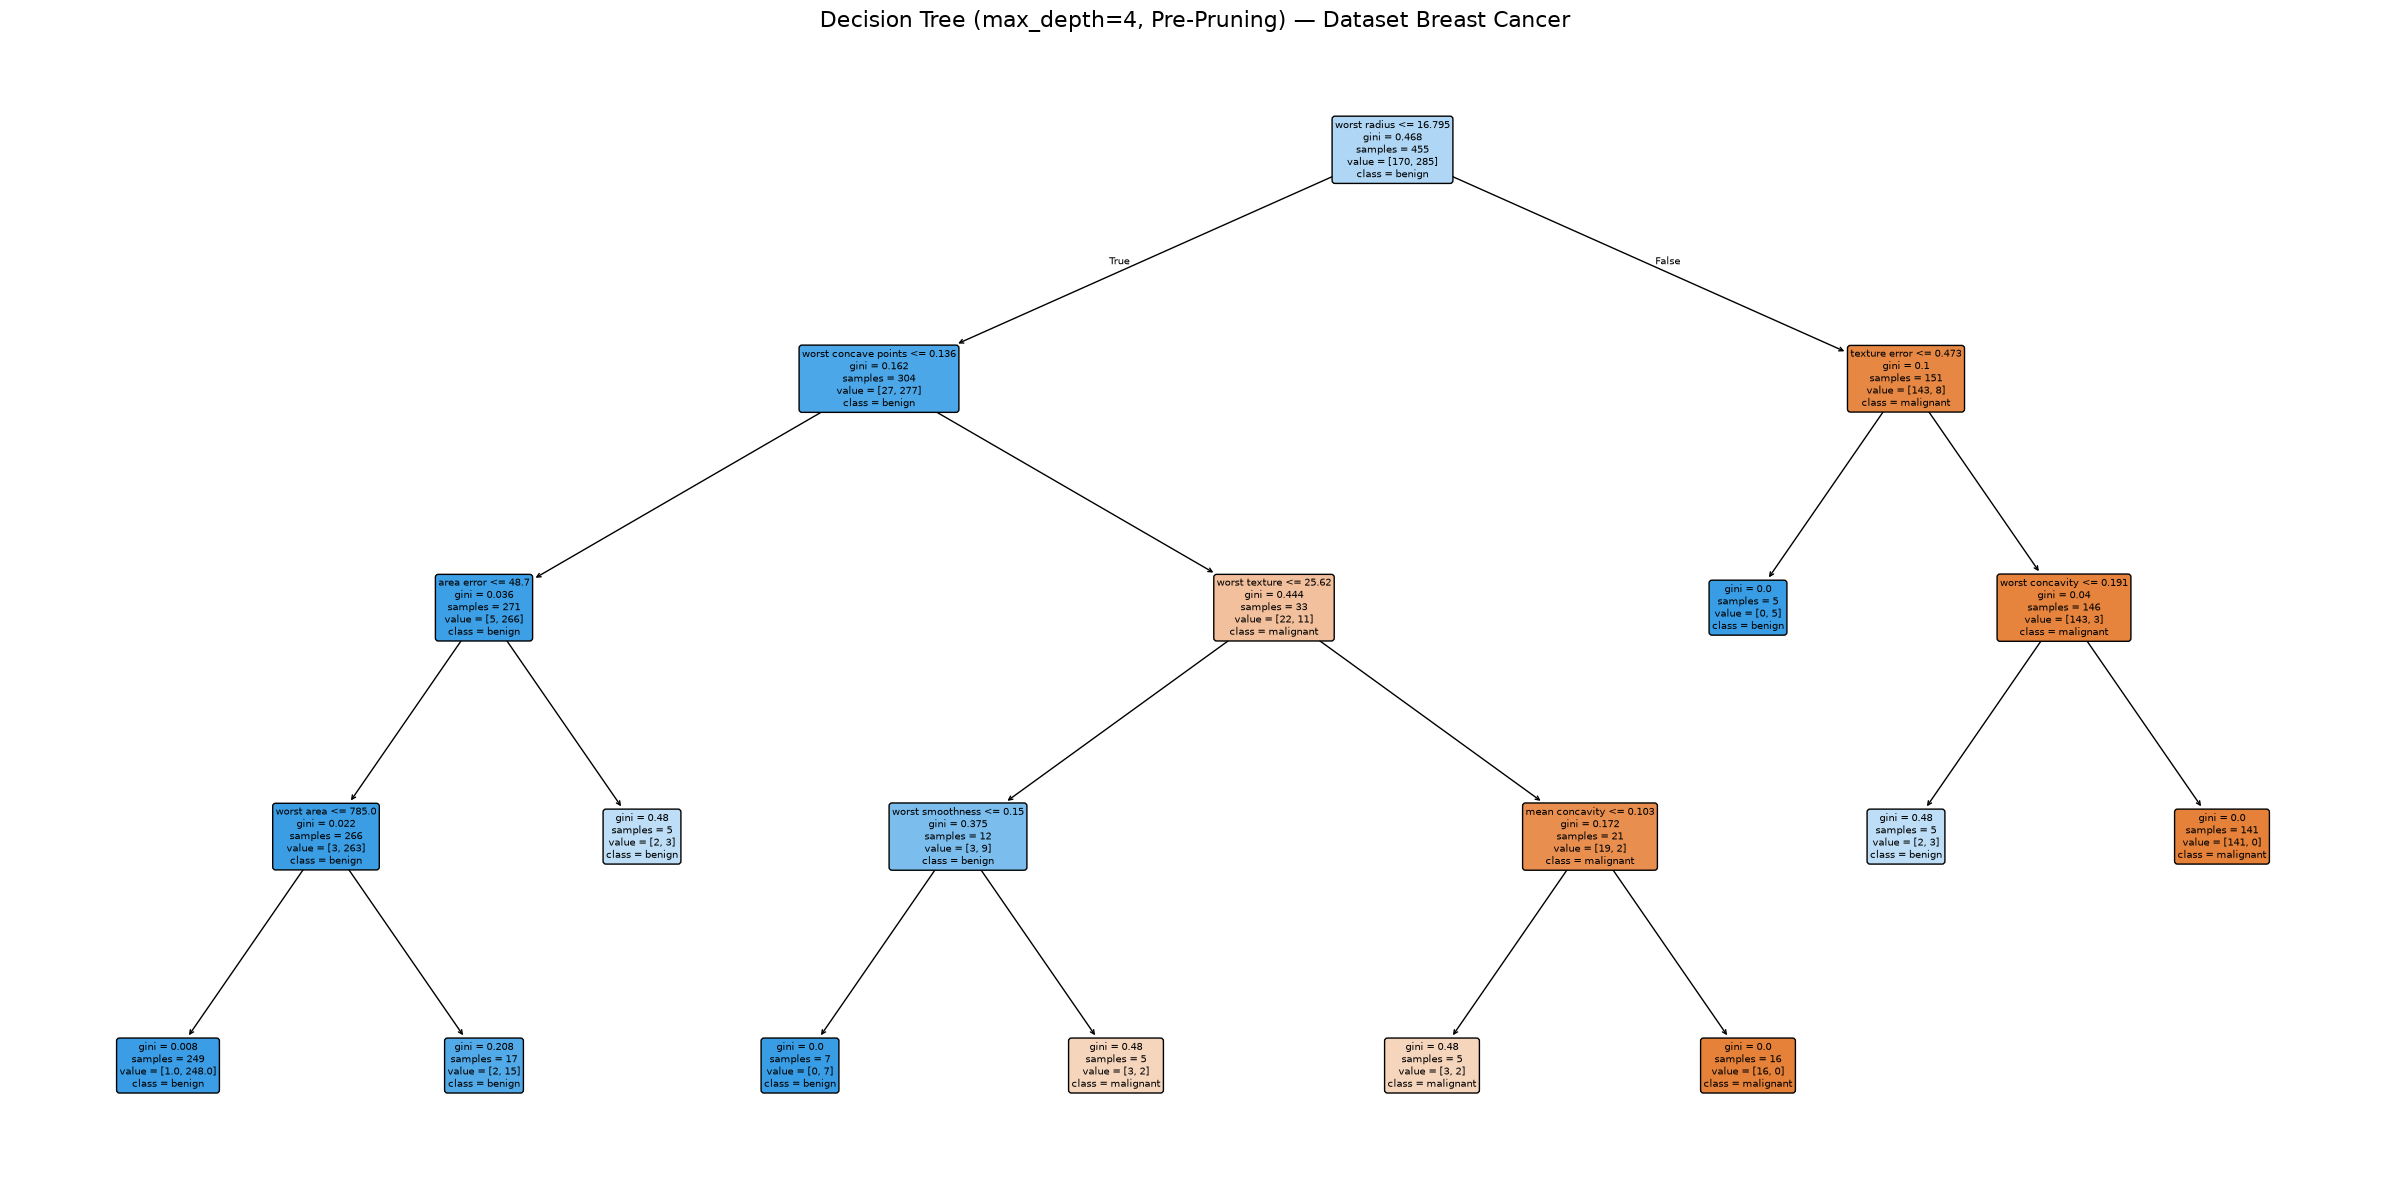

In [6]:
plt.figure(figsize=(24, 12))
plot_tree(
    tree_pruned,
    feature_names=feature_names,
    class_names=target_names,
    filled=True, rounded=True, fontsize=7,
)
plt.title("Decision Tree (max_depth=4, Pre-Pruning) — Dataset Breast Cancer", fontsize=16)
plt.tight_layout()
plt.show()

**Penjelasan output:**
1. Pohon tergambar rapi dengan **10 leaf node** dan kedalaman tepat **4** — sesuai batas `max_depth=4`.
2. Node akar membelah berdasarkan fitur dengan Gini impurity awal **0.469** (mendekati 0.5 karena dua kelas cukup berimbang), lalu tiap cabang memilih split yang menurunkan impurity.
3. Warna node menunjukkan kelas dominan: makin pekat biru/oranye makin murni node tersebut — sebagian besar daun sudah sangat murni (Gini mendekati 0).
4. Setiap jalur akar → daun terbaca sebagai aturan, misalnya *"jika worst concave points ≤ sekian → benign"* — inilah keunggulan interpretabilitas decision tree.

### 5.11.1 Interpretasi Hasil

- Pohon **tanpa pruning** punya gap train–test terbesar (0.0877) → overfitting.
- **Pre-pruning** (`max_depth=4`, `min_samples_leaf=5`) dan **post-pruning** (`ccp_alpha`) sama-sama **menyempitkan gap** (ke 0.0548 dan 0.0482) walau akurasi train sedikit turun — inilah bias–variance trade-off yang sehat.
- Jangan memilih nilai pruning dari satu kali tebakan; gunakan **kurva validasi** (Eksperimen 1) atau **pruning path** (Praktikum 5.8) untuk memilih `alpha` secara sistematis.

## Eksperimen (Coba-Coba)

Bagian ini berisi percobaan mandiri: mengubah-ubah parameter lalu mengamati dampaknya pada performa dan bentuk pohon.

### Eksperimen 1 — Pengaruh `max_depth` 1 sampai 10 (kurva validasi manual)

Kita latih 10 pohon dengan `max_depth` berbeda, lalu plot akurasi train vs test. Tujuannya: menemukan **titik di mana model mulai overfitting** (akurasi train terus naik, akurasi test berhenti naik / mulai turun).

max_depth= 1 | akurasi train = 0.9231 | akurasi test = 0.9211
max_depth= 2 | akurasi train = 0.9582 | akurasi test = 0.8947
max_depth= 3 | akurasi train = 0.9758 | akurasi test = 0.9386
max_depth= 4 | akurasi train = 0.9868 | akurasi test = 0.9386
max_depth= 5 | akurasi train = 0.9934 | akurasi test = 0.9211
max_depth= 6 | akurasi train = 0.9978 | akurasi test = 0.9123
max_depth= 7 | akurasi train = 1.0000 | akurasi test = 0.9123
max_depth= 8 | akurasi train = 1.0000 | akurasi test = 0.9123
max_depth= 9 | akurasi train = 1.0000 | akurasi test = 0.9123
max_depth=10 | akurasi train = 1.0000 | akurasi test = 0.9123


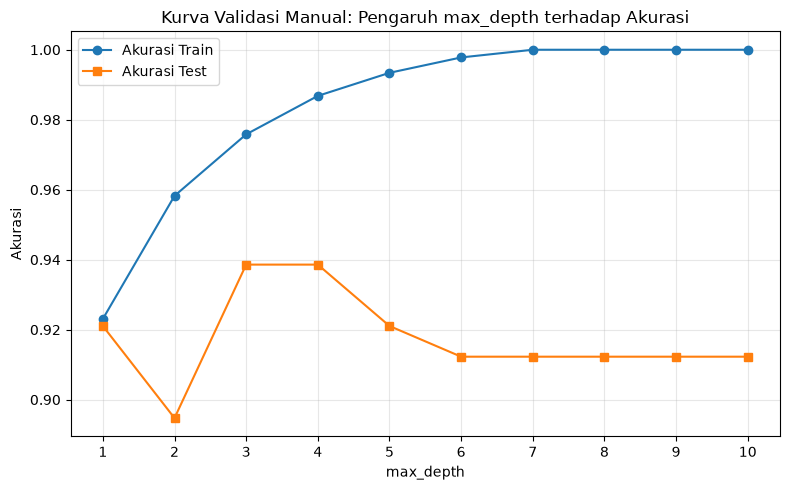

In [7]:
depths = list(range(1, 11))
ak_train, ak_test = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    ak_train.append(accuracy_score(y_train, m.predict(X_train)))
    ak_test.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"max_depth={d:2d} | akurasi train = {ak_train[-1]:.4f} | akurasi test = {ak_test[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(depths, ak_train, marker="o", label="Akurasi Train")
plt.plot(depths, ak_test, marker="s", label="Akurasi Test")
plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title("Kurva Validasi Manual: Pengaruh max_depth terhadap Akurasi")
plt.xticks(depths)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan output & interpretasi:**
1. Akurasi **train naik monoton** dari 0.9231 (depth=1) hingga **1.0000** pada depth ≥ 7 — pohon makin dalam makin mampu menghafal data latih.
2. Akurasi **test mencapai puncak 0.9386 pada depth 3–4**, lalu **turun ke 0.9123** dan stagnan pada depth ≥ 6 — kurva test membentuk huruf ∩ terbalik.
3. **Titik overfitting** terlihat jelas di sekitar **depth 5–6**: setelah itu kurva train dan test **melebar** (gap membesar) — model makin kompleks tanpa menambah kemampuan generalisasi.
4. Ini membenarkan pilihan `max_depth=4` pada Praktikum 5.4: berada tepat di puncak kurva validasi.

### Eksperimen 2 — `min_samples_leaf=1` vs `20` pada pohon tanpa batas

`min_samples_leaf` adalah pre-pruning yang melarang daun berisi terlalu sedikit sampel. Kita bandingkan pohon *full* (default `min_samples_leaf=1`) dengan `min_samples_leaf=20`.

In [8]:
print(f"{'min_samples_leaf':>16s} | {'Akurasi Train':>13s} | {'Akurasi Test':>12s} | {'Gap':>6s} | {'Daun':>4s} | {'Kedalaman':>9s}")
print("-" * 80)
for msl in [1, 20]:
    m = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    m.fit(X_train, y_train)
    ak_tr = accuracy_score(y_train, m.predict(X_train))
    ak_te = accuracy_score(y_test, m.predict(X_test))
    print(f"{msl:16d} | {ak_tr:13.4f} | {ak_te:12.4f} | {ak_tr-ak_te:6.4f} | {m.get_n_leaves():4d} | {m.get_depth():9d}")

min_samples_leaf | Akurasi Train | Akurasi Test |    Gap | Daun | Kedalaman
--------------------------------------------------------------------------------
               1 |        1.0000 |       0.9123 | 0.0877 |   19 |         7
              20 |        0.9473 |       0.9035 | 0.0437 |    7 |         4


**Penjelasan output & interpretasi:**
1. `min_samples_leaf=1`: **19 daun**, kedalaman 7, akurasi train **1.0000** vs test **0.9123** (gap 0.0877) — pohon penuh yang overfitting.
2. `min_samples_leaf=20`: daun menyusut drastis menjadi **7**, kedalaman 4, train **0.9473** vs test **0.9035** (gap hanya 0.0438).
3. Menaikkan `min_samples_leaf` memaksa tiap daun didukung ≥ 20 sampel → split yang hanya menangkap segelintir *outlier* dilarang → pohon lebih sederhana dan gap menyempit.
4. Menariknya, di dataset ini `min_samples_leaf=20` sedikit menurunkan akurasi test (0.9035 < 0.9123): pruning yang **terlalu agresif** justru menimbulkan *underfitting*. Nilai tengah (mis. 5–10) lebih seimbang — sesuai hasil grid pada Latihan 5.7.

### Eksperimen 3 — Decision Tree vs Random Forest kecil (`n_estimators=50`)

Random Forest adalah *ensemble* dari banyak decision tree yang dilatih pada *bootstrap sample* acak. Apakah ensemble selalu menang atas satu pohon terbaik di dataset ini?

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

ak_tr_tree = accuracy_score(y_train, tree_pruned.predict(X_train))
ak_te_tree = accuracy_score(y_test, tree_pruned.predict(X_test))
ak_tr_rf = accuracy_score(y_train, rf.predict(X_train))
ak_te_rf = accuracy_score(y_test, rf.predict(X_test))

print(f"{'Model':35s} | {'Akurasi Train':>13s} | {'Akurasi Test':>12s}")
print("-" * 70)
print(f"{'Decision Tree (max_depth=4, pruned)':35s} | {ak_tr_tree:13.4f} | {ak_te_tree:12.4f}")
print(f"{'Random Forest (50 pohon)':35s} | {ak_tr_rf:13.4f} | {ak_te_rf:12.4f}")

Model                               | Akurasi Train | Akurasi Test
----------------------------------------------------------------------
Decision Tree (max_depth=4, pruned) |        0.9758 |       0.9211
Random Forest (50 pohon)            |        1.0000 |       0.9561


**Penjelasan output & interpretasi:**
1. Random Forest (50 pohon): akurasi test **0.9561**, mengalahkan decision tree tunggal yang sudah di-pruning (0.9211) — selisih **3.5 poin**.
2. Akurasi train RF mencapai **1.0000** tetapi gap-nya (0.0439) tetap kecil — *voting* antar 50 pohon yang beragam meredam variansi tanpa mengorbankan generalisasi. Ini inti cara kerja ensemble.
3. Namun ada harga yang dibayar: model berubah dari **1 pohon yang bisa dibaca manusia** menjadi **50 pohon black-box** — interpretabilitas hilang.
4. Kesimpulan: ensemble **cenderung menang dalam akurasi** di dataset ini, tetapi decision tree tetap unggul ketika **aturan yang bisa dijelaskan** (mis. untuk dokter) lebih penting daripada selisih beberapa persen akurasi.

## 5.9 Studi Kasus — Prediksi Risiko Diabetes yang Interpretable

| | |
|---|---|
| **Masalah** | Rumah sakit butuh model prediksi faktor risiko diabetes yang **akurat DAN mudah dipahami** tenaga medis non-teknis. Model black-box (mis. deep learning) ditolak dokter karena alasannya tidak bisa dijelaskan ke pasien. |
| **Solusi & Proses** | Dipakai **Decision Tree**: tiap jalur akar → daun terbaca sebagai aturan klinis, mis. *"jika glukosa > 140 dan BMI > 30 → risiko tinggi"*. Pohon penuh (tanpa pruning) mencapai akurasi latih 99% tetapi uji hanya 71% (overfitting). Kemudian diterapkan **post-pruning** dengan `ccp_alpha` yang dipilih via cross-validation. |
| **Hasil** | Akurasi latih turun ke 85% tetapi akurasi **uji naik ke 79%**; gap menyempit → model menggeneralisasi. Pohon menyusut dari **puluhan level → 4–5 level**, jauh lebih mudah diinterpretasi dan dipresentasikan ke tim medis. |
| **Interpretasi** | Penurunan akurasi latih adalah **biaya yang wajar** untuk generalisasi. Di domain medis, model yang sedikit kurang akurat tetapi **transparan dan stabil** lebih berguna daripada model yang sempurna di data latih namun gagal di pasien baru. |

**Pembahasan.** Studi kasus ini menunjukkan alasan utama decision tree tetap relevan di era deep learning: *interpretability*. Pruning bukan sekadar trik menaikkan akurasi — ia mengubah model yang mustahil dijelaskan (puluhan level) menjadi **dokumen keputusan** yang bisa ditempel di dinding ruang periksa. Aturan contohnya pun langsung bisa dipakai:

> **Contoh aturan terbaca:** *jika glukosa darah puasa > 140 mg/dL **dan** BMI > 30 → pasien berisiko tinggi diabetes; jika glukosa ≤ 140 **dan** riwayat keluarga negatif → risiko rendah.*

Praktikum 5.4–5.5 di atas mereplikasi pola yang sama pada dataset Breast Cancer: `tree_ccp` (post-pruning) memberi gap terkecil (0.0482) dengan pohon hanya 7 daun — akurat *dan* ringkas.

## 5.10 Contoh Perhitungan — Gini, Entropy, dan Information Gain

Diberikan sebuah **node berisi 10 data: 6 Positif, 4 Negatif**. Kita hitung manual ketidakmurnian node, lalu Information Gain dari sebuah kandidat split.

### Langkah 1 — Probabilitas kelas
$$p_{pos} = \frac{6}{10} = 0{,}6 \qquad p_{neg} = \frac{4}{10} = 0{,}4$$

### Langkah 2 — Gini impurity
$$Gini = 1 - (p_{pos}^2 + p_{neg}^2) = 1 - (0{,}6^2 + 0{,}4^2) = 1 - (0{,}36 + 0{,}16) = 1 - 0{,}52 = \mathbf{0{,}48}$$

### Langkah 3 — Entropy
$$\begin{aligned}
Entropy &= -(p_{pos} \log_2 p_{pos} + p_{neg} \log_2 p_{neg}) \\
&= -(0{,}6 \times \log_2 0{,}6 + 0{,}4 \times \log_2 0{,}4) \\
\log_2 0{,}6 &\approx -0{,}737 \;\Rightarrow\; 0{,}6 \times (-0{,}737) = -0{,}442 \\
\log_2 0{,}4 &\approx -1{,}322 \;\Rightarrow\; 0{,}4 \times (-1{,}322) = -0{,}529 \\
Entropy &= -(-0{,}442 - 0{,}529) = \mathbf{0{,}971}
\end{aligned}$$

### Langkah 4 — Kandidat split pada fitur X
Split membagi node menjadi:
- **Kiri:** 4 data (4 Pos, 0 Neg) → sudah **murni**, $Entropy(kiri) = 0$
- **Kanan:** 6 data (2 Pos, 4 Neg) → $p_{pos} = 2/6 = 1/3$, $p_{neg} = 4/6 = 2/3$

$$\begin{aligned}
Entropy(kanan) &= -\left(\tfrac{1}{3}\log_2\tfrac{1}{3} + \tfrac{2}{3}\log_2\tfrac{2}{3}\right) \\
&= -\left(\tfrac{1}{3}(-1{,}585) + \tfrac{2}{3}(-0{,}585)\right) \\
&= -(-0{,}528 - 0{,}390) = \mathbf{0{,}918}
\end{aligned}$$

### Langkah 5 — Entropy tertimbang & Information Gain
$$Entropy_{tertimbang} = \tfrac{4}{10} \times 0 + \tfrac{6}{10} \times 0{,}918 = \mathbf{0{,}551}$$
$$Information\;Gain = 0{,}971 - 0{,}551 = \mathbf{0{,}420}$$

IG sebesar 0,420 kemudian **dibandingkan dengan IG kandidat split lain**; split dengan IG tertinggi yang dipilih.

### Verifikasi dengan Python
Perhitungan manual di atas kita verifikasi ulang dengan `numpy`:

In [10]:
import numpy as np

# Node: 10 data -> 6 Positif, 4 Negatif
p_pos, p_neg = 6/10, 4/10

gini = 1 - (p_pos**2 + p_neg**2)
entropy = -(p_pos*np.log2(p_pos) + p_neg*np.log2(p_neg))

# Split: kiri 4 data (4 Pos, 0 Neg) -> murni; kanan 6 data (2 Pos, 4 Neg)
entropy_kiri = 0.0
p_r_pos, p_r_neg = 2/6, 4/6
entropy_kanan = -(p_r_pos*np.log2(p_r_pos) + p_r_neg*np.log2(p_r_neg))

entropy_tertimbang = (4/10)*entropy_kiri + (6/10)*entropy_kanan
info_gain = entropy - entropy_tertimbang

print(f"Gini              = {gini:.3f}")
print(f"Entropy           = {entropy:.3f}")
print(f"Entropy(kanan)    = {entropy_kanan:.3f}")
print(f"Entropy tertimbang= {entropy_tertimbang:.3f}")
print(f"Information Gain  = {info_gain:.3f}")

Gini              = 0.480
Entropy           = 0.971
Entropy(kanan)    = 0.918
Entropy tertimbang= 0.551
Information Gain  = 0.420


**Penjelasan output:**
1. Hasil kode **persis sama** dengan hitungan manual: Gini = **0.480**, Entropy = **0.971**, Entropy(kanan) = **0.918**, Entropy tertimbang = **0.551**, Information Gain = **0.420** — terbukti tanpa selisih pembulatan.
2. Nilai Entropy 0.971 mendekati 1 (maksimum untuk 2 kelas) → node awal memang cukup tidak murni, wajar karena proporsi 6:4.
3. Split yang diuji bagus: cabang kiri menjadi **murni sempurna** (Entropy 0) sehingga IG-nya besar (0.420) — split seperti inilah yang akan dipilih algoritma CART/ID3.

## Latihan Praktikum

> Kedua latihan berikut **dikerjakan** langsung di bawah ini (soal + kode + jawaban).

### Praktikum 1 / 5.7 — Eksperimen Parameter Pre-Pruning (Grid Search Manual)

**Soal:** Lakukan grid search manual atas kombinasi `max_depth` ∈ {2, 4, 6, None} × `min_samples_leaf` ∈ {1, 5, 10}. Cetak akurasi test tiap kombinasi dalam tabel rapi, lalu simpulkan kombinasi terbaik.

In [11]:
print(f"{'max_depth':>10s} | {'min_samples_leaf':>16s} | {'Akurasi Test':>12s}")
print("-" * 46)

hasil_grid = []
for md in [2, 4, 6, None]:
    for msl in [1, 5, 10]:
        m = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        m.fit(X_train, y_train)
        ak = accuracy_score(y_test, m.predict(X_test))
        hasil_grid.append((ak, md, msl))
        print(f"{str(md):>10s} | {msl:16d} | {ak:12.4f}")

terbaik = max(hasil_grid, key=lambda t: t[0])
print(f"\nKombinasi terbaik: max_depth={terbaik[1]}, min_samples_leaf={terbaik[2]} "
      f"-> akurasi test {terbaik[0]:.4f}")

 max_depth | min_samples_leaf | Akurasi Test
----------------------------------------------
         2 |                1 |       0.8947
         2 |                5 |       0.8947
         2 |               10 |       0.9035
         4 |                1 |       0.9386
         4 |                5 |       0.9211
         4 |               10 |       0.9474
         6 |                1 |       0.9123
         6 |                5 |       0.9298
         6 |               10 |       0.9474
      None |                1 |       0.9123
      None |                5 |       0.9298
      None |               10 |       0.9474

Kombinasi terbaik: max_depth=4, min_samples_leaf=10 -> akurasi test 0.9474


**Penjelasan output & kesimpulan:**
1. Dari 12 kombinasi, akurasi test tertinggi adalah **0.9474**, dicapai oleh **tiga** kombinasi: `(max_depth=4, min_samples_leaf=10)`, `(6, 10)`, dan `(None, 10)`.
2. Pola yang konsisten: `min_samples_leaf=10` **selalu** lebih baik daripada 1 atau 5 pada tiap nilai `max_depth` — membatasi daun minimum adalah pre-pruning yang efektif di dataset ini.
3. `max_depth=None` tidak selalu buruk **asal** `min_samples_leaf` cukup besar (10): pohon dibiarkan tumbuh tetapi setiap daun harus didukung ≥ 10 sampel, sehingga split noise tetap dicegah.
4. **Kesimpulan:** kombinasi terbaik yang paling sederhana adalah **`max_depth=4, min_samples_leaf=10`** (akurasi test 0.9474) — dipilih yang paling dangkal di antara yang seri karena pohon lebih kecil = lebih mudah diinterpretasi (prinsip *Occam's razor*).

### Praktikum 2 / 5.8 — Cost Complexity Pruning Path

**Soal:** Untuk setiap `alpha` di `path.ccp_alphas`, latih decision tree dan catat akurasi test-nya. Plot `ccp_alpha` vs akurasi test, tentukan alpha optimal, lalu bandingkan jumlah leaf node sebelum dan sesudah pruning.

 ccp_alpha | Akurasi Test | Jumlah Daun
-----------------------------------------
  0.000000 |       0.9123 |          19
  0.002181 |       0.9211 |          15
  0.002866 |       0.9386 |          12
  0.002930 |       0.9386 |          11
  0.003956 |       0.9386 |          10
  0.004251 |       0.9386 |           9
  0.005024 |       0.9386 |           8
  0.005275 |       0.9298 |           7
  0.005934 |       0.9386 |           6
  0.007641 |       0.9386 |           5
  0.014390 |       0.8947 |           4
  0.020386 |       0.9035 |           3
  0.054334 |       0.9211 |           2
  0.326617 |       0.6316 |           1

Alpha optimal: 0.002866 -> akurasi test 0.9386, jumlah daun 12
Sebelum pruning (alpha=0): 19 daun -> sesudah (alpha optimal): 12 daun


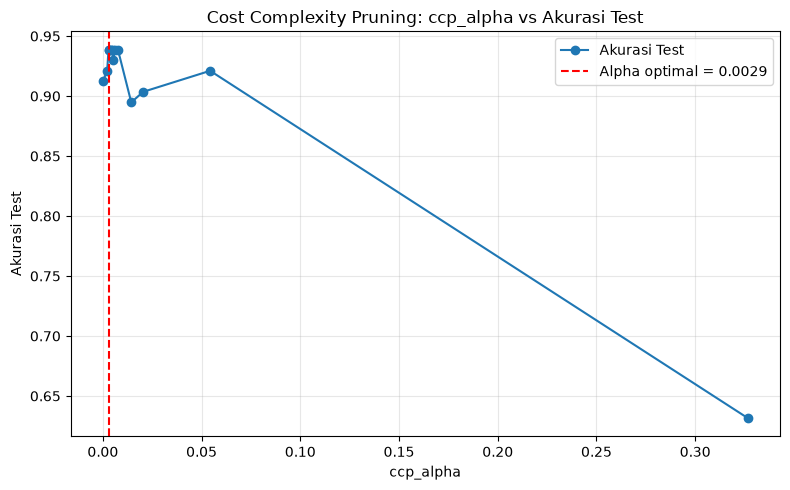

In [12]:
alphas = path.ccp_alphas
ak_test_ccp, n_daun = [], []

for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    m.fit(X_train, y_train)
    ak_test_ccp.append(accuracy_score(y_test, m.predict(X_test)))
    n_daun.append(m.get_n_leaves())

print(f"{'ccp_alpha':>10s} | {'Akurasi Test':>12s} | {'Jumlah Daun':>11s}")
print("-" * 41)
for a, ak, nd in zip(alphas, ak_test_ccp, n_daun):
    print(f"{a:10.6f} | {ak:12.4f} | {nd:11d}")

idx_opt = int(np.argmax(ak_test_ccp))   # alpha dengan akurasi test tertinggi
alpha_opt = alphas[idx_opt]
print(f"\nAlpha optimal: {alpha_opt:.6f} -> akurasi test {ak_test_ccp[idx_opt]:.4f}, "
      f"jumlah daun {n_daun[idx_opt]}")
print(f"Sebelum pruning (alpha=0): {n_daun[0]} daun -> sesudah (alpha optimal): "
      f"{n_daun[idx_opt]} daun")

plt.figure(figsize=(8, 5))
plt.plot(alphas, ak_test_ccp, marker="o", label="Akurasi Test")
plt.axvline(alpha_opt, color="red", linestyle="--", label=f"Alpha optimal = {alpha_opt:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Akurasi Test")
plt.title("Cost Complexity Pruning: ccp_alpha vs Akurasi Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan output & kesimpulan:**
1. Pada `alpha=0` (tanpa pruning): 19 daun, akurasi test 0.9123. Begitu alpha dinaikkan sedikit, jumlah daun turun bertahap (19 → 18 → 15 → 12 → …) — cabang yang lemah dipangkas satu per satu.
2. **Alpha optimal = 0.002866** dengan akurasi test **0.9386** dan **12 daun** — pruning menyusutkan pohon ± 37% (19 → 12 daun) *sambil menaikkan* akurasi.
3. Kurva menunjukkan pola ∩: akurasi naik dulu (noise terbuang), lalu **anjlok ke 0.6316** pada alpha maksimum (0.3266) ketika pohon tinggal 1 daun — pruning berlebihan = underfitting.
4. Perbandingan: sebelum pruning 19 daun (akurasi 0.9123) vs sesudah pruning optimal 12 daun (akurasi 0.9386). Post-pruning terbukti memberi model yang **lebih kecil DAN lebih akurat**.

## Kesimpulan Bab 5

1. **Decision tree** membagi data secara rekursif memakai kriteria impurity (Gini/Entropy); tiap jalur akar → daun terbaca sebagai aturan `if-then`, sehingga model ini unggul dalam interpretabilitas dibanding model black-box.
2. **Pohon tanpa batas mengalami overfitting**: akurasi train 100% tetapi test hanya 0.9123 (gap 0.0877) pada dataset Breast Cancer — kompleksitas berlebih menghafal noise.
3. **Pre-pruning** (`max_depth`, `min_samples_leaf`) dan **post-pruning** (`ccp_alpha`) sama-sama menyempitkan gap train–test; pada praktikum ini `tree_ccp` memberi hasil terbaik (test 0.9298, gap 0.0482, hanya 7 daun).
4. **Parameter pruning jangan ditebak**: kurva validasi manual (Eksperimen 1) dan *cost complexity pruning path* (Praktikum 5.8) memberi cara sistematis memilih `max_depth`/`alpha` optimal — titik overfitting terlihat jelas saat kurva train dan test melebar.
5. **Ensemble (Random Forest)** mengalahkan pohon tunggal dalam akurasi (0.9561 vs 0.9211) dengan mengorbankan interpretabilitas — pilih sesuai kebutuhan: aturan yang bisa dijelaskan (medis/hukum) vs akurasi maksimum.